# 02 — ML Pipeline
## Feature Reduction (Two-Stage Filter) + Model Training + Evaluation

**Pipeline 5 bước:**
1. Load dữ liệu từ Parquet
2. Tiền xử lý: fillna(0) → LabelEncoder → MinMaxScaler
3. **Two-Stage Feature Selection** — Stage 1: Chi-square (Relevance) + Stage 2: Correlation Filter (Redundancy)
4. Train: RF / SVM / KNN / NB / MLP / XGBoost
5. Đánh giá: Stratified 5-Fold CV, Accuracy / Precision / Recall / F1 / MCC / ROC-AUC

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
import time
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, matthews_corrcoef, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

BASE_DIR     = Path(r'H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020')
PARQUET_PATH = BASE_DIR / 'csv' / 'feature_vectors_static.parquet'
CSV_PATH     = BASE_DIR / 'csv' / 'feature_vectors_static.csv'
# File dynamic (140 features) chứa cột 'Class' — cùng 11,598 APK, cùng thứ tự
LABEL_CSV    = BASE_DIR / 'csv' / 'other csvs' / 'feature_vectors_syscalls_frequency_5_Cat.csv'
OUT_DIR      = BASE_DIR / 'processed'
FIG_DIR      = BASE_DIR / 'notebooks' / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Mapping theo CICMalDroid 2020 paper (UNB dataset page)
CLASS_MAP = {1: 'Adware', 2: 'Banking', 3: 'SMS', 4: 'Riskware', 5: 'Benign',
             1.0: 'Adware', 2.0: 'Banking', 3.0: 'SMS', 4.0: 'Riskware', 5.0: 'Benign'}

print('Paths OK')

Paths OK


## 2. Load & Tiền xử lý

In [2]:
# Load static features (dùng parquet nếu có)
if PARQUET_PATH.exists():
    df = pd.read_parquet(PARQUET_PATH, engine='pyarrow')
    print(f'[OK] Loaded from Parquet: {df.shape}')
else:
    print('[INFO] Loading from CSV...')
    df = pd.read_csv(CSV_PATH, low_memory=False)
    df.to_parquet(PARQUET_PATH, engine='pyarrow', compression='snappy', index=False)
    print(f'[OK] Loaded & saved Parquet: {df.shape}')

# Gán nhãn từ dynamic CSV (static CSV không có cột nhãn)
# Cả hai dataset đều có 11,598 APK theo cùng thứ tự → join theo index
LABEL_COL = 'Class'
label_series = pd.read_csv(LABEL_CSV, usecols=['Class'])['Class']
df[LABEL_COL] = label_series.map(CLASS_MAP).values

print(f'Label column: "{LABEL_COL}"')
print(f'Unique classes ({df[LABEL_COL].nunique()}): {sorted(df[LABEL_COL].dropna().unique().tolist())}')
print(f'Label distribution:\n{df[LABEL_COL].value_counts().to_string()}')

[OK] Loaded from Parquet: (11598, 50621)
Label column: "Class"
Unique classes (5): ['Adware', 'Banking', 'Benign', 'Riskware', 'SMS']
Label distribution:
Class
SMS         3904
Riskware    2546
Banking     2100
Benign      1795
Adware      1253


In [3]:
# Tách X và y
X_raw = df.drop(columns=[LABEL_COL]).copy()
y_raw = df[LABEL_COL].copy()

# Encode nhãn
le = LabelEncoder()
y  = le.fit_transform(y_raw.astype(str))
print(f'Classes: {le.classes_.tolist()}')
print(f'Encoded: {dict(zip(le.classes_, range(len(le.classes_))))}')

# Lưu encoder
joblib.dump(le, OUT_DIR / 'label_encoder.pkl')

# Lưu tên tất cả features (cần cho inference)
all_feature_names = list(X_raw.columns)
with open(OUT_DIR / 'all_feature_names.pkl', 'wb') as f:
    pickle.dump(all_feature_names, f)
print(f'\nSaved: label_encoder.pkl, all_feature_names.pkl ({len(all_feature_names)} features)')

Classes: ['Adware', 'Banking', 'Benign', 'Riskware', 'SMS']
Encoded: {'Adware': 0, 'Banking': 1, 'Benign': 2, 'Riskware': 3, 'SMS': 4}

Saved: label_encoder.pkl, all_feature_names.pkl (50621 features)


In [4]:
# Tiền xử lý
print('[1] Drop cột 100% NaN...')
all_nan_cols = X_raw.columns[X_raw.isna().all()].tolist()
X_raw = X_raw.drop(columns=all_nan_cols)
print(f'    Dropped {len(all_nan_cols)} all-NaN columns')

print('[2] fillna(0)  — NaN = đặc trưng không tồn tại trong APK...')
X_filled = X_raw.fillna(0)

print('[3] Encode cột object còn lại...')
le_feat = LabelEncoder()
for col in X_filled.select_dtypes(include='object').columns:
    X_filled[col] = le_feat.fit_transform(X_filled[col].astype(str))

print('[4] MinMaxScaler...')
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_filled.values.astype(float))
feature_names_after_drop = list(X_raw.columns)

joblib.dump(scaler, OUT_DIR / 'scaler.pkl')
with open(OUT_DIR / 'feature_names_after_drop.pkl', 'wb') as f:
    pickle.dump(feature_names_after_drop, f)

print(f'\nX_scaled shape: {X_scaled.shape}')
print('Saved: scaler.pkl, feature_names_after_drop.pkl')

[1] Drop cột 100% NaN...
    Dropped 18931 all-NaN columns
[2] fillna(0)  — NaN = đặc trưng không tồn tại trong APK...
[3] Encode cột object còn lại...
[4] MinMaxScaler...

X_scaled shape: (11598, 31690)
Saved: scaler.pkl, feature_names_after_drop.pkl


## 3. Two-Stage Feature Selection

Phương pháp lọc hai bước giải quyết cả hai tiêu chí:

**Stage 1 — Relevance (Chi-square):**  
Xếp hạng từng feature độc lập theo độ phụ thuộc thống kê với nhãn lớp (χ²-test).  
Giữ top-k features có điểm χ² cao nhất. Nhanh: O(n×m).

**Stage 2 — Redundancy (Correlation Filter):**  
Loại bỏ các features có hệ số tương quan Pearson ρ > 0.95 với feature đã chọn (ưu tiên giữ feature có điểm χ² cao hơn).  
Giải quyết điểm yếu univariate của Chi-square: đảm bảo không có thông tin trùng lặp.

**K vs F1 Elbow Analysis:**  
Đánh giá F1 tại các giá trị k khác nhau (RF nhanh + 3-fold CV) để tìm điểm "elbow" — nơi thêm feature không còn cải thiện đáng kể hiệu suất phân loại.

In [5]:
def two_stage_feature_selection(
    X: np.ndarray, y: np.ndarray, feature_names: list,
    k_stage1: int = 2000, corr_threshold: float = 0.95,
) -> tuple:
    """
    Two-Stage Filter Feature Selection:
      Stage 1 — Relevance  : Chi-square SelectKBest (univariate, O(n×m), fast)
      Stage 2 — Redundancy : Pearson correlation filter (ρ > corr_threshold)

    Trả về: (selected_global_idx, selected_names, chi2_scores_all, chi2_pval_all)
    """
    n_feat = X.shape[1]
    k = min(k_stage1, n_feat)

    print(f'[Stage 1] Chi-square SelectKBest — top {k:,} / {n_feat:,} features...')
    t0 = time.time()
    selector = SelectKBest(chi2, k=k)
    selector.fit(X, y)
    stage1_idx    = selector.get_support(indices=True)   # global feature indices
    stage1_scores = selector.scores_[stage1_idx]
    print(f'          Done in {time.time()-t0:.1f}s')

    print(f'[Stage 2] Correlation filter (ρ > {corr_threshold}) on {k:,} features...')
    t0 = time.time()
    # Sort by chi2 score descending — prefer high-relevance features in conflict
    order       = np.argsort(stage1_scores)[::-1]
    ordered_idx = stage1_idx[order]            # global idx sorted by chi2 score
    X_ordered   = X[:, ordered_idx].astype(float)

    kept_flags = np.ones(len(order), dtype=bool)
    kept_vecs  = []  # unit-normalized vectors of features already kept

    for i in range(len(order)):
        xi     = X_ordered[:, i]
        norm_i = np.linalg.norm(xi)
        if norm_i < 1e-10:
            kept_flags[i] = False
            continue
        xi_u = xi / norm_i
        if any(abs(np.dot(xi_u, xj_u)) > corr_threshold for xj_u in kept_vecs):
            kept_flags[i] = False
        else:
            kept_vecs.append(xi_u)

    final_local  = np.where(kept_flags)[0]
    final_global = ordered_idx[final_local]
    final_names  = [feature_names[i] for i in final_global]
    print(f'          Done in {time.time()-t0:.1f}s — {len(stage1_idx):,} → {len(final_names):,} features')

    return final_global, final_names, selector.scores_, selector.pvalues_


# ── K vs F1 Elbow Analysis ───────────────────────────────────────────────────
# Dùng RF nhanh (n_estimators=30, max_depth=10) + 3-fold CV
# để ước tính F1 tại các giá trị k → tìm điểm "elbow"
K_VALUES = [50, 100, 200, 500, 1000, 1500, 2000, 3000]
rf_probe = RandomForestClassifier(n_estimators=30, max_depth=10,
                                  n_jobs=-1, random_state=42)

k_f1_results = []
print(f'\n{"k":>5}  {"F1-weighted (3-fold)":>22}  {"Elapsed":>9}')
print('─' * 44)
for k_val in K_VALUES:
    t0    = time.time()
    k_use = min(k_val, X_scaled.shape[1])
    X_tmp = SelectKBest(chi2, k=k_use).fit_transform(X_scaled, y)
    cv_f1 = cross_val_score(rf_probe, X_tmp, y, cv=3,
                            scoring='f1_weighted', n_jobs=-1).mean()
    k_f1_results.append((k_use, float(cv_f1)))
    print(f'{k_use:>5}  {cv_f1:>22.4f}  {time.time()-t0:>8.1f}s')

k_vals_arr  = np.array([r[0] for r in k_f1_results])
f1_vals_arr = np.array([r[1] for r in k_f1_results])

# Elbow detection: smallest k where F1 is within tolerance of the peak
# (peak = maximum F1 across all k values tested)
peak_f1   = f1_vals_arr.max()
tolerance = 0.005   # chấp nhận F1 trong vòng 0.5% so với đỉnh
elbow_k   = int(k_vals_arr[-1])  # fallback: largest k
for k_val, f1_val in zip(k_vals_arr, f1_vals_arr):
    if f1_val >= peak_f1 - tolerance:
        elbow_k = int(k_val)
        break
print(f'\n[OK] Elbow analysis hoàn thành.')
print(f'     Peak F1 = {peak_f1:.4f} @ k = {int(k_vals_arr[np.argmax(f1_vals_arr)])}')
print(f'     Elbow k = {elbow_k}  (smallest k ≥ peak_f1 − {tolerance})')


    k    F1-weighted (3-fold)    Elapsed
────────────────────────────────────────────
   50                  0.8733       9.4s
  100                  0.8927       6.6s
  200                  0.9617       6.7s
  500                  0.9682       6.8s
 1000                  0.9664       6.9s
 1500                  0.9613       7.1s
 2000                  0.9616       8.0s
 3000                  0.9598       8.6s

[OK] Elbow analysis hoàn thành.
     Peak F1 = 0.9682 @ k = 500
     Elbow k = 500  (smallest k ≥ peak_f1 − 0.005)


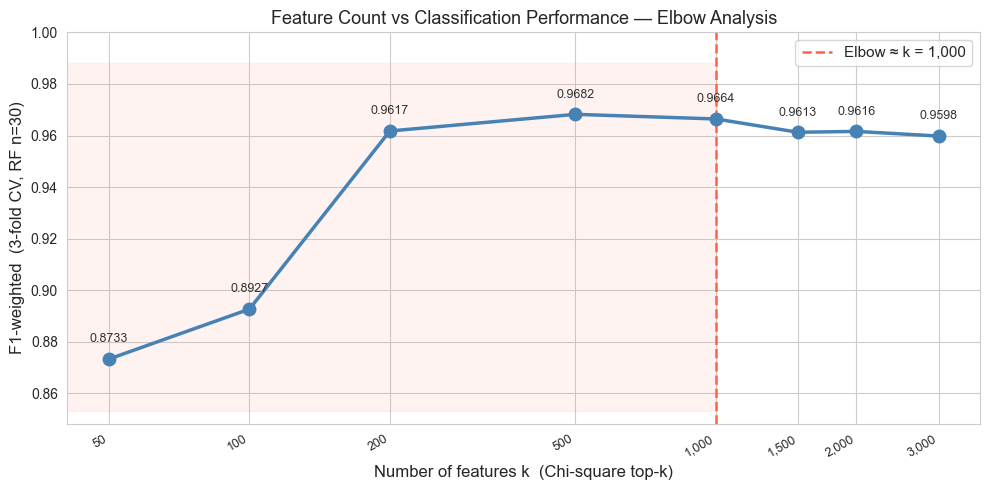

Saved: 07_k_vs_f1_elbow.png  |  Elbow tại k = 1,000

Running Two-Stage Feature Selection  (k=1000, ρ≤0.95)...
[Stage 1] Chi-square SelectKBest — top 1,000 / 31,690 features...
          Done in 3.9s
[Stage 2] Correlation filter (ρ > 0.95) on 1,000 features...
          Done in 47.3s — 1,000 → 516 features

✓ Tổng thời gian  : 51.2s
✓ Features        : 31,690 → 1,000 (Stage 1) → 516 (Stage 2)
✓ Tỉ lệ giảm      : 98.4%
✓ X_sel shape     : (11598, 516)
Saved: selected_features.pkl


In [6]:
# ── Vẽ K vs F1 Elbow Curve ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_vals_arr, f1_vals_arr, 'o-', color='steelblue',
        linewidth=2.5, markersize=9, zorder=3)

for k, f in zip(k_vals_arr, f1_vals_arr):
    ax.annotate(f'{f:.4f}', (k, f),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=9, color='#333')

# Tự động phát hiện elbow: điểm đầu tiên mà F1 tăng < 0.002 so với bước trước
elbow_k = int(k_vals_arr[-1])
for i in range(1, len(k_vals_arr)):
    if f1_vals_arr[i] - f1_vals_arr[i - 1] < 0.002:
        elbow_k = int(k_vals_arr[i])
        break

ax.axvline(elbow_k, color='tomato', linestyle='--', linewidth=1.8,
           label=f'Elbow ≈ k = {elbow_k:,}')
ax.fill_betweenx([f1_vals_arr.min() - 0.02, f1_vals_arr.max() + 0.02],
                  0, elbow_k, alpha=0.07, color='tomato')

ax.set_xlabel('Number of features k  (Chi-square top-k)', fontsize=12)
ax.set_ylabel('F1-weighted  (3-fold CV, RF n=30)', fontsize=12)
ax.set_title('Feature Count vs Classification Performance — Elbow Analysis', fontsize=13)
ax.set_xscale('log')
# Hiển thị đúng giá trị k trên trục x (không phải 10^n)
ax.set_xticks(k_vals_arr)
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.set_xticklabels([f'{int(k):,}' for k in k_vals_arr], rotation=30, ha='right', fontsize=9)
ax.xaxis.set_minor_locator(plt.matplotlib.ticker.NullLocator())
ax.legend(fontsize=11)
ax.set_ylim(max(0.0, f1_vals_arr.min() - 0.025),
            min(1.0, f1_vals_arr.max() + 0.035))
plt.tight_layout()
plt.savefig(FIG_DIR / '07_k_vs_f1_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: 07_k_vs_f1_elbow.png  |  Elbow tại k = {elbow_k:,}')

# ── Chạy Two-Stage với K đã chọn ────────────────────────────────────────────
K_STAGE1    = elbow_k  # tự động chọn từ elbow analysis (không hardcode)
CORR_THRESH = 0.95   # ngưỡng loại redundancy (Stage 2)

print(f'\nRunning Two-Stage Feature Selection  (k={K_STAGE1}, ρ≤{CORR_THRESH})...')
t_total = time.time()
selected_global_idx, selected_features, chi2_scores_all, chi2_pval_all = \
    two_stage_feature_selection(
        X_scaled, y, feature_names_after_drop,
        k_stage1=K_STAGE1, corr_threshold=CORR_THRESH,
    )
X_sel = X_scaled[:, selected_global_idx]

print(f'\n✓ Tổng thời gian  : {time.time()-t_total:.1f}s')
print(f'✓ Features        : {X_scaled.shape[1]:,} → {K_STAGE1:,} (Stage 1) → {len(selected_features):,} (Stage 2)')
print(f'✓ Tỉ lệ giảm      : {(1 - len(selected_features)/X_scaled.shape[1])*100:.1f}%')
print(f'✓ X_sel shape     : {X_sel.shape}')

with open(OUT_DIR / 'selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)
print('Saved: selected_features.pkl')

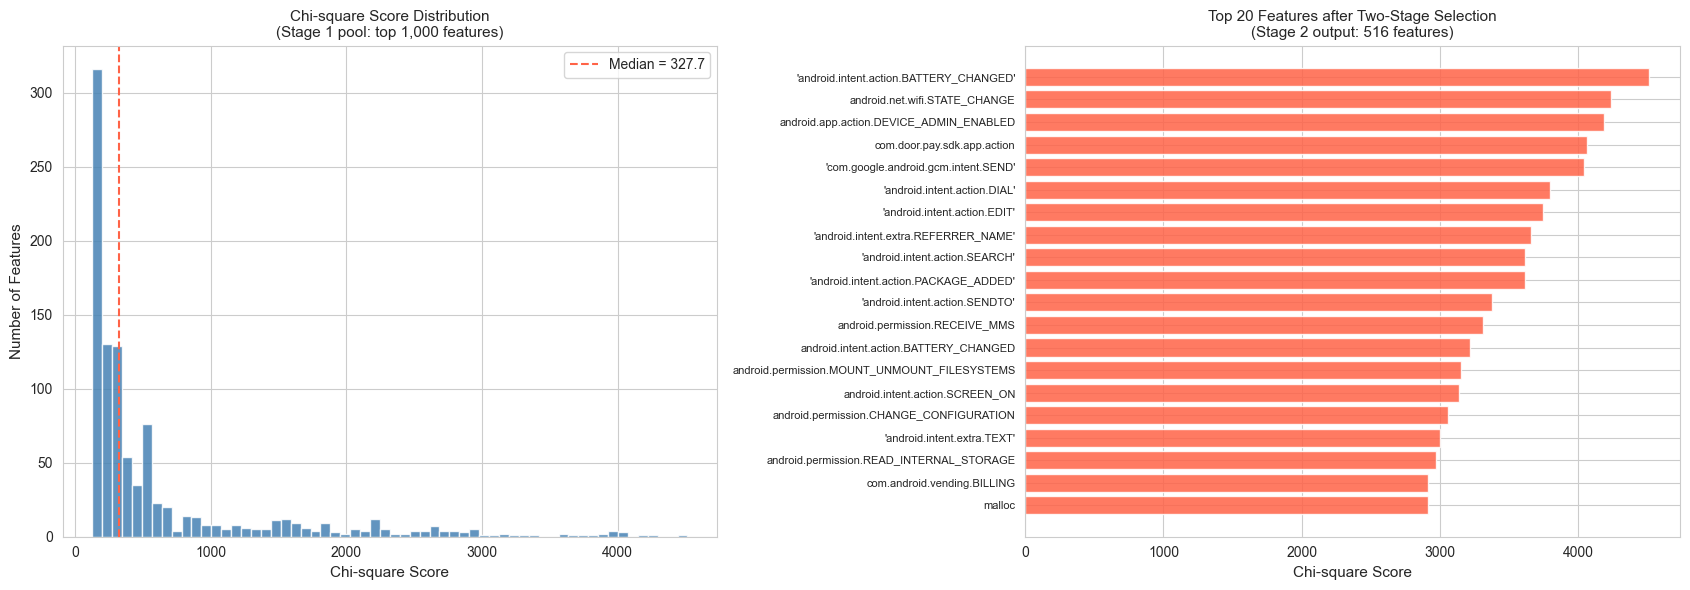

Saved: 08_feature_selection_results.png


In [7]:
# Visualize Two-Stage Feature Selection Results
# Left : Chi-square score distribution (Stage 1 pool)
# Right: Top 20 final features (after both stages)

# Chi-square scores for the Stage 1 pool
stage1_mask   = SelectKBest(chi2, k=K_STAGE1).fit(X_scaled, y).get_support(indices=True)
stage1_scores_vis = chi2_scores_all[stage1_mask]

# Rank selected features by chi2 score
sel_chi2_pairs = sorted(
    [(feature_names_after_drop[i], chi2_scores_all[i]) for i in selected_global_idx],
    key=lambda x: -x[1]
)
top20_names  = [p[0][:55] for p in sel_chi2_pairs[:20]]
top20_scores = [p[1]       for p in sel_chi2_pairs[:20]]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Left: distribution of chi2 scores in Stage 1 pool
axes[0].hist(stage1_scores_vis, bins=60, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].axvline(np.median(stage1_scores_vis), color='tomato', linestyle='--', linewidth=1.5,
                label=f'Median = {np.median(stage1_scores_vis):.1f}')
axes[0].set_xlabel('Chi-square Score', fontsize=11)
axes[0].set_ylabel('Number of Features', fontsize=11)
axes[0].set_title(f'Chi-square Score Distribution\n(Stage 1 pool: top {K_STAGE1:,} features)', fontsize=11)
axes[0].legend()

# Right: top 20 final selected features
y_pos = range(len(top20_names))
axes[1].barh(y_pos, top20_scores[::-1], color='tomato', alpha=0.85, edgecolor='white')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(top20_names[::-1], fontsize=8)
axes[1].set_xlabel('Chi-square Score', fontsize=11)
axes[1].set_title(
    f'Top 20 Features after Two-Stage Selection\n'
    f'(Stage 2 output: {len(selected_features):,} features)',
    fontsize=11,
)

plt.tight_layout()
plt.savefig(FIG_DIR / '08_feature_selection_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: 08_feature_selection_results.png')

## 4. Model Training — Stratified 5-Fold Cross-Validation

In [8]:
def evaluate(y_true, y_pred, y_proba=None) -> dict:
    """Tính 6 metrics: Accuracy, Precision, Recall, F1, MCC, ROC-AUC."""
    n_classes = len(np.unique(y_true))
    m = {
        'accuracy':  float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, average='weighted', zero_division=0)),
        'recall':    float(recall_score(y_true, y_pred, average='weighted', zero_division=0)),
        'f1':        float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'mcc':       float(matthews_corrcoef(y_true, y_pred)),
    }
    if y_proba is not None:
        try:
            if n_classes == 2:
                m['roc_auc'] = float(roc_auc_score(y_true, y_proba[:, 1]))
            else:
                m['roc_auc'] = float(roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted'))
        except Exception:
            pass
    return m


CLASSIFIERS = {
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', random_state=42),
        {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
    ),
    'SVM (Linear)': (
        SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42),
        {'C': [0.3, 1.0, 3.0]}
    ),
    'k-NN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 11], 'metric': ['euclidean', 'manhattan']}
    ),
    'Naive Bayes': (
        GaussianNB(),
        {}
    ),
    'MLP (Neural Net)': (
        MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=500,
                      early_stopping=True, random_state=42),
        {'alpha': [1e-4, 1e-3, 1e-2], 'learning_rate_init': [1e-3, 1e-2]}
    ),
}

# Thêm XGBoost nếu cài đặt được
try:
    from xgboost import XGBClassifier
    CLASSIFIERS['XGBoost'] = (
        XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [3, 6], 'learning_rate': [0.05, 0.1]}
    )
    print('[OK] XGBoost available')
except ImportError:
    print('[WARN] XGBoost không có sẵn. Cài bằng: pip install xgboost')

print(f'\nModels to train: {list(CLASSIFIERS.keys())}')
print(f'Feature set    : {X_sel.shape[1]:,} features (Two-Stage), {X_sel.shape[0]:,} samples')

[OK] XGBoost available

Models to train: ['Random Forest', 'SVM (Linear)', 'k-NN', 'Naive Bayes', 'MLP (Neural Net)', 'XGBoost']
Feature set    : 516 features (Two-Stage), 11,598 samples


In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_results = {}

for name, (clf_base, param_grid) in CLASSIFIERS.items():
    print(f'\n{"─"*50}')
    print(f'  Training: {name}')
    print(f'{"─"*50}')
    t0 = time.time()

    fold_preds, fold_true, fold_probas = [], [], []
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_sel, y), 1):
        X_tr, X_val = X_sel[tr_idx], X_sel[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        if param_grid:
            n_iter = 3 if name == 'SVM (Linear)' else 5
            cv_inner = 2 if name == 'SVM (Linear)' else 3
            search = RandomizedSearchCV(
                clf_base, param_grid, n_iter=n_iter, cv=cv_inner,
                scoring='f1_weighted', random_state=42, n_jobs=-1
            )
            search.fit(X_tr, y_tr)
            clf_fold = search.best_estimator_
        else:
            clf_fold = clf_base.__class__(**clf_base.get_params())
            clf_fold.fit(X_tr, y_tr)

        y_pred = clf_fold.predict(X_val)
        fold_preds.extend(y_pred)
        fold_true.extend(y_val)
        try:
            fold_probas.extend(clf_fold.predict_proba(X_val))
        except Exception:
            pass

        fm = evaluate(y_val, y_pred)
        fold_scores.append(fm)
        print(f'  Fold {fold} — acc={fm["accuracy"]:.4f}  f1={fm["f1"]:.4f}  mcc={fm["mcc"]:.4f}')

    # Tổng hợp
    probas_arr = np.array(fold_probas) if fold_probas else None
    overall    = evaluate(np.array(fold_true), np.array(fold_preds), probas_arr)
    avg = {k: float(np.mean([s[k] for s in fold_scores if k in s]))
           for k in ['accuracy', 'precision', 'recall', 'f1', 'mcc']}
    avg['roc_auc']          = overall.get('roc_auc')
    avg['confusion_matrix'] = confusion_matrix(fold_true, fold_preds).tolist()
    avg['train_time_s']     = round(time.time() - t0, 1)

    all_results[name] = avg

    print(f'  AVG — acc={avg["accuracy"]:.4f}  f1={avg["f1"]:.4f}  mcc={avg["mcc"]:.4f}  '
          f'auc={avg.get("roc_auc", "N/A")}  ({avg["train_time_s"]}s)')

    # Retrain final model
    if param_grid:
        final_search = RandomizedSearchCV(
            clf_base, param_grid, n_iter=n_iter if 'n_iter' in dir() else 5,
            cv=3, scoring='f1_weighted', random_state=42, n_jobs=-1
        )
        final_search.fit(X_sel, y)
        final_clf = final_search.best_estimator_
    else:
        final_clf = clf_base.__class__(**clf_base.get_params())
        final_clf.fit(X_sel, y)

    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    joblib.dump(final_clf, OUT_DIR / f'model_{safe_name}.pkl')

print('\n[DONE] Tất cả models đã train xong!')


──────────────────────────────────────────────────
  Training: Random Forest
──────────────────────────────────────────────────
  Fold 1 — acc=0.9862  f1=0.9862  mcc=0.9821
  Fold 2 — acc=0.9901  f1=0.9901  mcc=0.9872
  Fold 3 — acc=0.9888  f1=0.9888  mcc=0.9855
  Fold 4 — acc=0.9845  f1=0.9844  mcc=0.9799
  Fold 5 — acc=0.9909  f1=0.9909  mcc=0.9883
  AVG — acc=0.9881  f1=0.9881  mcc=0.9846  auc=0.9998422983683994  (25.5s)

──────────────────────────────────────────────────
  Training: SVM (Linear)
──────────────────────────────────────────────────
  Fold 1 — acc=0.9845  f1=0.9845  mcc=0.9799
  Fold 2 — acc=0.9871  f1=0.9871  mcc=0.9832
  Fold 3 — acc=0.9780  f1=0.9780  mcc=0.9715
  Fold 4 — acc=0.9780  f1=0.9780  mcc=0.9715
  Fold 5 — acc=0.9853  f1=0.9853  mcc=0.9810
  AVG — acc=0.9826  f1=0.9826  mcc=0.9774  auc=0.9990438779885344  (58.1s)

──────────────────────────────────────────────────
  Training: k-NN
──────────────────────────────────────────────────
  Fold 1 — acc=0.9603  

In [10]:
# ── XGBoost — Chạy riêng sau khi cài xgboost ────────────────────────────────
# Cell này train XGBoost độc lập và append vào all_results đã có
# Chạy cell này mà KHÔNG cần chạy lại toàn bộ cell training ở trên

try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError('XGBoost chưa được cài. Chạy: uv pip install xgboost')

xgb_name  = 'XGBoost'
xgb_base  = XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1)
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth':    [3, 6],
    'learning_rate':[0.05, 0.1],
}

print(f'\n{"─"*50}')
print(f'  Training: {xgb_name}')
print(f'{"─"*50}')
t0 = time.time()

fold_preds, fold_true, fold_probas = [], [], []
fold_scores_xgb = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_sel, y), 1):
    X_tr, X_val = X_sel[tr_idx], X_sel[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    search = RandomizedSearchCV(
        xgb_base, xgb_params, n_iter=5, cv=3,
        scoring='f1_weighted', random_state=42, n_jobs=-1
    )
    search.fit(X_tr, y_tr)
    clf_fold = search.best_estimator_

    y_pred = clf_fold.predict(X_val)
    fold_preds.extend(y_pred)
    fold_true.extend(y_val)
    try:
        fold_probas.extend(clf_fold.predict_proba(X_val))
    except Exception:
        pass

    fm = evaluate(y_val, y_pred)
    fold_scores_xgb.append(fm)
    print(f'  Fold {fold} — acc={fm["accuracy"]:.4f}  f1={fm["f1"]:.4f}  mcc={fm["mcc"]:.4f}')

# Tổng hợp kết quả
probas_arr = np.array(fold_probas) if fold_probas else None
overall    = evaluate(np.array(fold_true), np.array(fold_preds), probas_arr)
avg = {k: float(np.mean([s[k] for s in fold_scores_xgb if k in s]))
       for k in ['accuracy', 'precision', 'recall', 'f1', 'mcc']}
avg['roc_auc']          = overall.get('roc_auc')
avg['confusion_matrix'] = confusion_matrix(fold_true, fold_preds).tolist()
avg['train_time_s']     = round(time.time() - t0, 1)

# Append vào all_results (không làm mất kết quả cũ)
all_results[xgb_name] = avg
print(f'  AVG — acc={avg["accuracy"]:.4f}  f1={avg["f1"]:.4f}  '
      f'mcc={avg["mcc"]:.4f}  auc={avg.get("roc_auc", "N/A")}  ({avg["train_time_s"]}s)')

# Retrain trên toàn bộ dữ liệu và lưu model
final_search = RandomizedSearchCV(
    xgb_base, xgb_params, n_iter=5, cv=3,
    scoring='f1_weighted', random_state=42, n_jobs=-1
)
final_search.fit(X_sel, y)
joblib.dump(final_search.best_estimator_, OUT_DIR / 'model_XGBoost.pkl')
print(f'Saved: model_XGBoost.pkl  |  best params: {final_search.best_params_}')
print(f'\nall_results hiện có {len(all_results)} models: {list(all_results.keys())}')


──────────────────────────────────────────────────
  Training: XGBoost
──────────────────────────────────────────────────
  Fold 1 — acc=0.9991  f1=0.9991  mcc=0.9989
  Fold 2 — acc=0.9996  f1=0.9996  mcc=0.9994
  Fold 3 — acc=1.0000  f1=1.0000  mcc=1.0000
  Fold 4 — acc=1.0000  f1=1.0000  mcc=1.0000
  Fold 5 — acc=0.9991  f1=0.9991  mcc=0.9989
  AVG — acc=0.9996  f1=0.9996  mcc=0.9994  auc=0.9999996136286254  (56.5s)
Saved: model_XGBoost.pkl  |  best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}

all_results hiện có 6 models: ['Random Forest', 'SVM (Linear)', 'k-NN', 'Naive Bayes', 'MLP (Neural Net)', 'XGBoost']


## 5. So sánh kết quả — Bảng tổng hợp

In [11]:
metrics_cols = ['accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc', 'train_time_s']
df_results = pd.DataFrame({
    name: {k: v for k, v in res.items() if k in metrics_cols}
    for name, res in all_results.items()
}).T

df_results = df_results.round(4)
df_results = df_results.sort_values('f1', ascending=False)
print(df_results.to_string())

# Lưu kết quả
df_results.to_csv(OUT_DIR / 'model_comparison.csv')
print('\nSaved: model_comparison.csv')

                  accuracy  precision  recall      f1     mcc  roc_auc  train_time_s
XGBoost             0.9996     0.9996  0.9996  0.9996  0.9994   1.0000          56.5
Random Forest       0.9881     0.9882  0.9881  0.9881  0.9846   0.9998          25.5
MLP (Neural Net)    0.9849     0.9850  0.9849  0.9849  0.9804   0.9989         181.2
SVM (Linear)        0.9826     0.9826  0.9826  0.9826  0.9774   0.9990          58.1
k-NN                0.9592     0.9595  0.9592  0.9591  0.9471   0.9882          69.1
Naive Bayes         0.8213     0.8576  0.8213  0.8220  0.7779   0.9436           0.7

Saved: model_comparison.csv


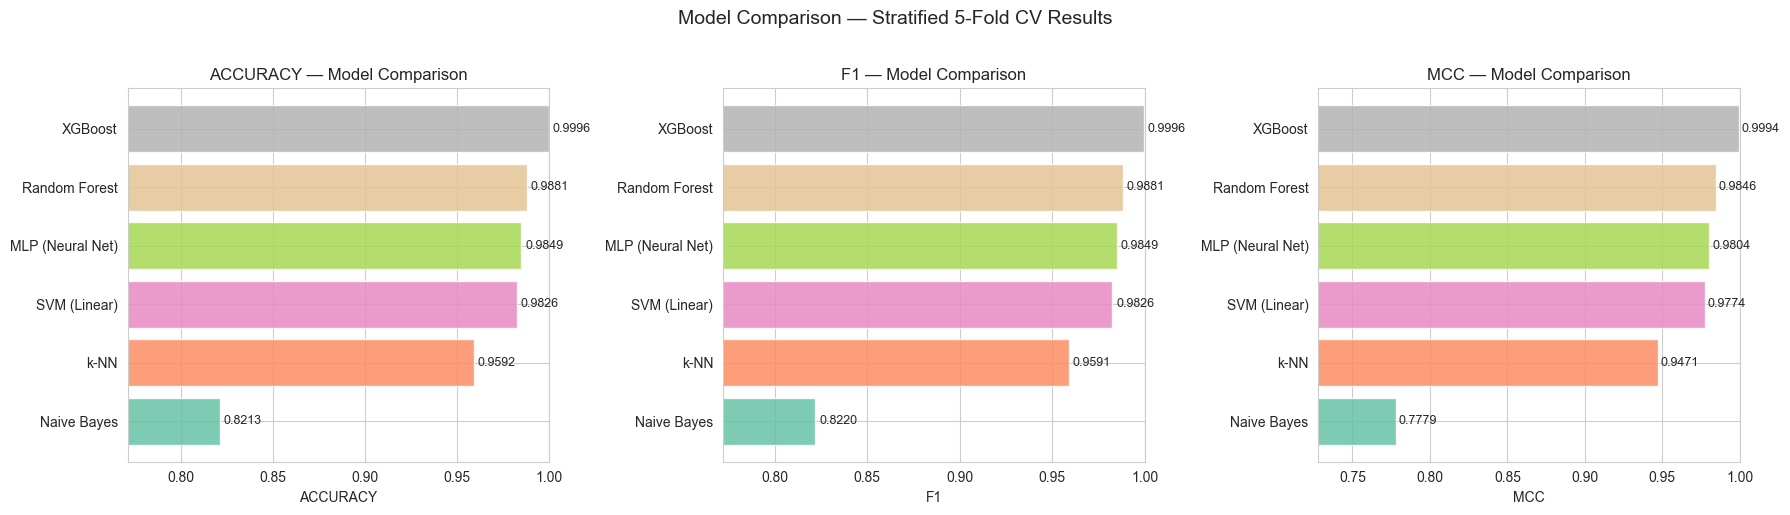

In [12]:
# Bar chart so sánh models
plot_metrics = ['accuracy', 'f1', 'mcc']
df_plot = df_results[plot_metrics].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(df_plot)))

for ax, metric in zip(axes, plot_metrics):
    vals  = df_plot[metric].sort_values(ascending=True)
    bars  = ax.barh(vals.index, vals.values,
                    color=colors[:len(vals)], alpha=0.85)
    ax.set_xlabel(metric.upper())
    ax.set_title(f'{metric.upper()} — Model Comparison')
    ax.set_xlim(max(0, vals.min() - 0.05), 1.0)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — Stratified 5-Fold CV Results', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Confusion Matrix — Best Model

Best model: XGBoost
F1-weighted: 0.9996


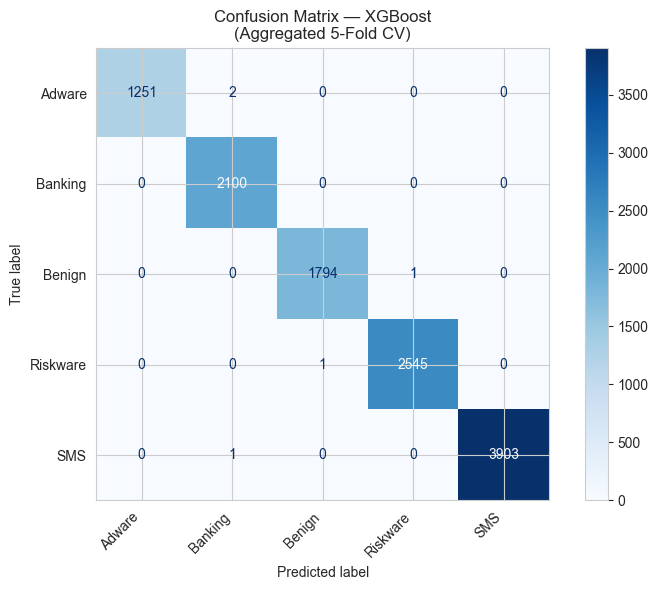

In [13]:
best_model_name = df_results['f1'].astype(float).idxmax()
best_cm         = np.array(all_results[best_model_name]['confusion_matrix'])

print(f'Best model: {best_model_name}')
print(f'F1-weighted: {all_results[best_model_name]["f1"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=best_cm,
    display_labels=le.classes_
)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Confusion Matrix — {best_model_name}\n(Aggregated 5-Fold CV)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Lưu model tốt nhất + artifacts

In [14]:
safe_best = best_model_name.replace(' ', '_').replace('(', '').replace(')', '')
best_model_path = OUT_DIR / f'model_{safe_best}.pkl'

# Copy vào model_best.pkl
import shutil
shutil.copy2(best_model_path, OUT_DIR / 'model_best.pkl')

# Lưu numpy labels
np.save(str(OUT_DIR / 'y_encoded.npy'), y)

# Summary
import json
summary = {
    'best_model': best_model_name,
    'n_features_selected': len(selected_features),
    'n_features_total':    len(all_feature_names),
    'n_samples':           int(X_scaled.shape[0]),
    'label_classes':       le.classes_.tolist(),
    'cv_folds':            5,
    'metrics_best': {
        k: all_results[best_model_name][k]
        for k in ['accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc']
    }
}
with open(OUT_DIR / 'pipeline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('=== Artifacts saved ===')
for p in sorted(OUT_DIR.glob('*')):
    size = p.stat().st_size / 1024
    print(f'  {p.name:<40} {size:.1f} KB')

print(f'\n[DONE] Best model: {best_model_name}')
print(f'  F1-weighted : {all_results[best_model_name]["f1"]:.4f}')
print(f'  MCC         : {all_results[best_model_name]["mcc"]:.4f}')
print(f'  ROC-AUC     : {all_results[best_model_name].get("roc_auc", "N/A")}')
print(f'\nBước tiếp theo → 03_inference.ipynb')

=== Artifacts saved ===
  all_feature_names.pkl                    3820.3 KB
  feature_names_after_drop.pkl             2757.4 KB
  label_encoder.pkl                        0.5 KB
  model_best.pkl                           854.5 KB
  model_comparison.csv                     0.4 KB
  model_k-NN.pkl                           46845.8 KB
  model_MLP_Neural_Net.pkl                 4083.3 KB
  model_Naive_Bayes.pkl                    41.2 KB
  model_Random_Forest.pkl                  9231.6 KB
  model_SVM_Linear.pkl                     4341.5 KB
  model_XGBoost.pkl                        854.5 KB
  pipeline_summary.json                    0.5 KB
  scaler.pkl                               1238.5 KB
  selected_features.pkl                    25.7 KB
  y_encoded.npy                            90.7 KB

[DONE] Best model: XGBoost
  F1-weighted : 0.9996
  MCC         : 0.9994
  ROC-AUC     : 0.9999996136286254

Bước tiếp theo → 03_inference.ipynb
